In [9]:
import itertools
from datasets import load_dataset

N_LINES = 300
STEP = 50          # keep 1 line out of every 50
SPLIT = "test"

ds = load_dataset("CATMuS/medieval", split=SPLIT, streaming=True)

every_nth = (row for i, row in enumerate(ds) if i % STEP == 0)
samples = list(itertools.islice(every_nth, N_LINES))

print(f"Loaded {len(samples)} lines")
print("Languages:", sorted({row["language"] for row in samples}))
print("Centuries:", sorted({row["century"] for row in samples}))

Resolving data files:   0%|          | 0/252 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Loaded 300 lines
Languages: ['Castilian', 'Catalan', 'French', 'Italian', 'Latin']
Centuries: [10, 11, 12, 13, 14, 15, 16]


# look at one line

True text : fazer merçed ⁊ qnt̃o biẽ yo pudiere Et
Language  : Castilian
Century   : 14
Script    : Hybrida


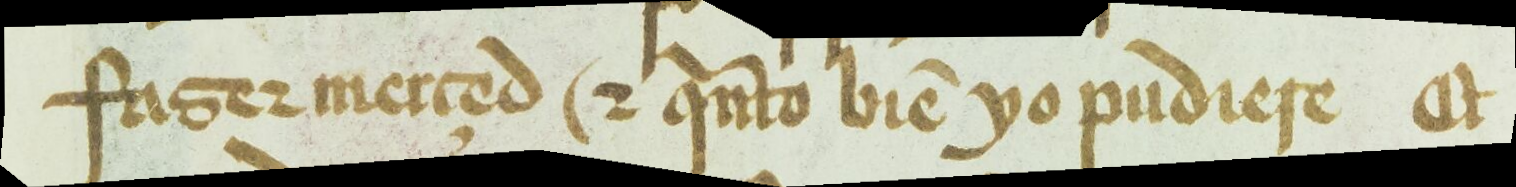

In [10]:
row = samples[0]
print("True text :", row["text"])
print("Language  :", row["language"])
print("Century   :", row["century"])
print("Script    :", row["script_type"])
row["im"]

# Load the model

In [11]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_ID = "medieval-data/trocr-medieval-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained(MODEL_ID)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_ID).to(device).eval()
print("Model loaded on", device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded on cuda


# Let the model read the 50 lines

In [17]:
def read_line(image):
    pixel_values = processor(images=image.convert("RGB"), return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pixel_values, max_new_tokens=128, num_beams=4, no_repeat_ngram_size=4)
    return processor.batch_decode(ids, skip_special_tokens=True)[0]

predictions = []
for i, row in enumerate(samples, start=1):
    predictions.append(read_line(row["im"]))
    if i % 10 == 0:
        print(f"{i}/{len(samples)} lines read")

10/300 lines read
20/300 lines read
30/300 lines read
40/300 lines read
50/300 lines read
60/300 lines read
70/300 lines read
80/300 lines read
90/300 lines read
100/300 lines read
110/300 lines read
120/300 lines read
130/300 lines read
140/300 lines read
150/300 lines read
160/300 lines read
170/300 lines read
180/300 lines read
190/300 lines read
200/300 lines read
210/300 lines read
220/300 lines read
230/300 lines read
240/300 lines read
250/300 lines read
260/300 lines read
270/300 lines read
280/300 lines read
290/300 lines read
300/300 lines read


# Measure the errors: Character Error Rate

In [18]:
import unicodedata

def normalise(s):
    # Same Unicode form on both sides, so 'e' + accent and 'é' count as equal.
    return unicodedata.normalize("NFC", s).strip()

def edit_distance(a, b):
    # Classic dynamic programming: prev[j] = cost of turning a[:i-1] into b[:j].
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        cur = [i]
        for j, cb in enumerate(b, start=1):
            cur.append(min(prev[j] + 1,                 # delete
                           cur[j - 1] + 1,              # insert
                           prev[j - 1] + (ca != cb)))   # replace (free if equal)
        prev = cur
    return prev[-1]

def cer(truth, pred):
    truth, pred = normalise(truth), normalise(pred)
    return edit_distance(truth, pred) / max(len(truth), 1)

# Check with the worked example above
assert edit_distance("ffecha", "fecha") == 1
print("Example CER:", round(cer("ffecha", "fecha"), 2))

Example CER: 0.17


# Results

In [19]:
import pandas as pd

rows = []
for row, pred in zip(samples, predictions):
    truth = normalise(row["text"])
    rows.append({
        "language": row["language"],
        "century": row["century"],
        "script": row["script_type"],
        "truth": truth,
        "prediction": normalise(pred),
        "edits": edit_distance(truth, normalise(pred)),
        "length": len(truth),
    })

df = pd.DataFrame(rows)
df["cer"] = df["edits"] / df["length"].clip(lower=1)

# Overall CER = all edits / all true characters (long lines weigh more than short ones)
overall = df["edits"].sum() / df["length"].sum()
print(f"Overall CER on {len(df)} lines: {overall:.1%}")

Overall CER on 300 lines: 19.1%


# By language

In [20]:
by_lang = df.groupby("language").agg(lines=("cer", "size"), edits=("edits", "sum"), chars=("length", "sum"))
by_lang["cer"] = (by_lang["edits"] / by_lang["chars"]).map("{:.1%}".format)
by_lang.sort_values("lines", ascending=False)

,lines,edits,chars,cer
language,,,,
Latin,156,1342,5199,25.8%
French,83,306,2905,10.5%
Italian,31,171,1093,15.6%
Castilian,24,197,1252,15.7%
Catalan,6,24,244,9.8%


# best and worst lines

In [21]:
pd.set_option("display.max_colwidth", 80)
cols = ["language", "century", "truth", "prediction", "cer"]
print("Best 5")
display(df.sort_values("cer").head(5)[cols])
print("Worst 5")
display(df.sort_values("cer", ascending=False).head(5)[cols])

Best 5


,language,century,truth,prediction,cer
1,Castilian,14,comigo q̃ero q̃ tomedes por la ynfanta,comigo q̃ero q̃ tomedes por la ynfanta,0.0
47,French,13,a haute uoiz. Qnͣt ce oirent li frere,a haute uoiz. Qnͣt ce oirent li frere,0.0
42,French,13,arme ꝯme ch̾r seur gnͣt cheuax,arme ꝯme ch̾r seur gnͣt cheuax,0.0
41,French,13,la uesteure quil li auoit dou,la uesteure quil li auoit dou,0.0
55,French,13,deu. mais tout le trespasserent ke nul bñ,deu. mais tout le trespasserent ke nul bñ,0.0


Worst 5


,language,century,truth,prediction,cer
271,Latin,12,80,Noͣ,1.500000
297,Latin,13,duĩ.,i lũ.,1.000000
92,French,15,Mamour,Vt lauoue,1.000000
205,Latin,10,85,252,1.000000
211,Latin,10,"ΔΙΚΑΙΩ ΔΙΚΑΙΟC, ΠΟΙΩ ΠΟΕΜΛ ΠΟΗΤΗC, ΛΕΠΙΞΩ, ΛΕΠΙC ΟΦΕΟC, ΛΕΠΙC ΑΡixIPOY",assa ter aixa ne liuo. Ie auo. ⁊ que Reniꝵio. desrico he oc. aene adrab,0.957746
